# Análisis de la estacionalidad de la demanda turística
## Pregunta de negocio

¿En qué meses se concentra la demanda turística en los destinos donde opera StaySpain?

Fuente:
Encuesta de Ocupación Hotelera (EOH) - INE

Periodo:
2023-2025

## Objetivo

Analizar la distribución mensual de las pernoctaciones en los destinos donde opera
StaySpain para identificar la existencia de patrones estacionales.

La EOH utiliza las pernoctaciones como principal indicador de demanda turística, este análisis permitirá identificar los meses de mayor actividad
y apoyar decisiones relacionadas con precios, disponibilidad y campañas de marketing.

# 1. Carga de librerías y configuración

In [294]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Carga del dataset

In [295]:


# Parámetros de ejecución

fecha_EDA = pd.Timestamp.today().strftime("%d/%m/%Y")

PERIODO_INICIO = pd.Timestamp("2023-01-01")
PERIODO_FIN = pd.Timestamp("2025-12-01")


# Localizar automáticamente la raíz del proyecto

def encontrar_raiz_proyecto(nombre_carpeta="Equip_34"):
    """
    Sube desde el directorio actual hasta encontrar
    la carpeta raíz del proyecto.
    """
    actual = Path.cwd()

    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta

    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre_carpeta}' subiendo desde {actual}"
    )


raiz_proyecto = encontrar_raiz_proyecto("Equip_34")

ruta_csv = (
    raiz_proyecto
    / "Data"
    / "clean_dataset_INE_EOH_20_07_2026.csv"
)


# Cargar datos

df = pd.read_csv(
    ruta_csv,
    sep=";",
    encoding="utf-8-sig"
)


# Información general

print(f"Fecha de ejecución : {fecha_EDA}")
print(f"Periodo analizado  : {PERIODO_INICIO.strftime('%Y-%m')} → {PERIODO_FIN.strftime('%Y-%m')}")
print(f"Ruta resuelta      : {ruta_csv}")
print(f"Observaciones      : {df.shape[0]:,}")
print(f"Variables          : {df.shape[1]}")

display(df.head())

C:\Users\lacal\AppData\Local\Temp\ipykernel_140752\1009393707.py:38: DtypeWarning: Columns (5,29,30,33,38,39,40,41,42,43,44,45,46,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Fecha de ejecución : 24/07/2026
Periodo analizado  : 2023-01 → 2025-12
Ruta resuelta      : c:\Users\lacal\Desktop\IT_ACADEMY\simulador\ProjecteData\Equip_34\Data\clean_dataset_INE_EOH_20_07_2026.csv
Observaciones      : 118,224
Variables          : 48


,tabla,nivel_geo,codigo_ine,geo,geo_key,zona_ccaa,dimension,categoria,categoria_key,metrica,unidad,nivel_jerarquico,periodo,fecha,anio,mes,mes_nombre,mes_nombre_corto,trimestre,anio_mes,orden_anio_mes,anio_completo,periodo_comparacion_2023_2025,periodo_principal_2025,valor,sin_dato,es_dato_no_publicado,provisional,serie_enlazada,mercado_stayspain,tipo_mercado,provincia_referencia,ccaa_referencia,mercados_relacionados,ambito_sprint4,es_demanda_destino,es_procedencia_nacional,es_total_territorial,estancia_media,pct_nacional,pct_extranjero,total_nacional_provincia,valor_estimado_origen,estancia_media_origen,temporada_demanda,ranking_mes_demanda_2023_2025,indice_estacional_base_100,pct_mes_demanda_2023_2025
0,2039,zona_turistica,NaN,Barcelona,barcelona,Cataluña,residencia,Residentes en España,residentes en espana,pernoctaciones,noches,desglose,2023M01,2023-01-01,2023,1,Enero,Ene,T1,2023-01,202301,True,True,False,"290645,0",False,False,False,False,NaN,NaN,NaN,NaN,NaN,False,False,False,False,"1,8542182356393702","20,75844440048024","79,24155559951977",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2039,zona_turistica,NaN,Barcelona,barcelona,Cataluña,residencia,Residentes en España,residentes en espana,pernoctaciones,noches,desglose,2023M02,2023-02-01,2023,2,Febrero,Feb,T1,2023-02,202302,True,True,False,"291958,0",False,False,False,False,NaN,NaN,NaN,NaN,NaN,False,False,False,False,"2,007591437628501","18,578076370696124","81,42192362930388",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2039,zona_turistica,NaN,Barcelona,barcelona,Cataluña,residencia,Residentes en España,residentes en espana,pernoctaciones,noches,desglose,2023M03,2023-03-01,2023,3,Marzo,Mar,T1,2023-03,202303,True,True,False,"331684,0",False,False,False,False,NaN,NaN,NaN,NaN,NaN,False,False,False,False,"1,9346604994079666","18,146753423675737","81,85324657632427",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2039,zona_turistica,NaN,Barcelona,barcelona,Cataluña,residencia,Residentes en España,residentes en espana,pernoctaciones,noches,desglose,2023M04,2023-04-01,2023,4,Abril,Abr,T2,2023-04,202304,True,True,False,"284262,0",False,False,False,False,NaN,NaN,NaN,NaN,NaN,False,False,False,False,"2,010794522098353","13,779246640284018","86,22075335971599",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2039,zona_turistica,NaN,Barcelona,barcelona,Cataluña,residencia,Residentes en España,residentes en espana,pernoctaciones,noches,desglose,2023M05,2023-05-01,2023,5,Mayo,May,T2,2023-05,202305,True,True,False,"307100,0",False,False,False,False,NaN,NaN,NaN,NaN,NaN,False,False,False,False,"1,843447986073594","14,651668625152492","85,3483313748475",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [296]:
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [297]:
# Convertir la variable valor a numérica
df["valor"] = (
    df["valor"]
    .astype(str)
    .str.replace(".", "", regex=False)   # elimina separador de miles si existe
    .str.replace(",", ".", regex=False)  # cambia coma decimal por punto
)

df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

# 2. Validación inicial del dataset

In [298]:
print("Información general")

df.info()

Información general
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118224 entries, 0 to 118223
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   tabla                          118224 non-null  int64         
 1   nivel_geo                      118224 non-null  object        
 2   codigo_ine                     109656 non-null  float64       
 3   geo                            118224 non-null  object        
 4   geo_key                        118224 non-null  object        
 5   zona_ccaa                      6912 non-null    object        
 6   dimension                      118224 non-null  object        
 7   categoria                      118224 non-null  object        
 8   categoria_key                  118224 non-null  object        
 9   metrica                        118224 non-null  object        
 10  unidad                         118224 non-null  

In [299]:
print("Valores nulos")

display(
    df.isna()
      .sum()
      .sort_values(ascending=False))

Valores nulos


temporada_demanda                117072
ranking_mes_demanda_2023_2025    117072
indice_estacional_base_100       117072
pct_mes_demanda_2023_2025        117072
tipo_mercado                     117072
mercado_stayspain                117072
zona_ccaa                        111312
mercados_relacionados            105552
provincia_referencia             105480
ccaa_referencia                  104400
pct_nacional                      86032
pct_extranjero                    86032
estancia_media                    80992
estancia_media_origen             50916
valor_estimado_origen             50492
total_nacional_provincia          49824
codigo_ine                         8568
valor                              5416
mes                                   0
anio                                  0
nivel_jerarquico                      0
unidad                                0
fecha                                 0
periodo                               0
categoria                             0


In [300]:
print("Duplicados")

print(
    f"Filas duplicadas: {df.duplicated().sum()}")

Duplicados
Filas duplicadas: 0


In [301]:
print("Variables numéricas")

display(
    df.describe().T)

Variables numéricas


,count,mean,min,25%,50%,75%,max,std
tabla,118224.0,2069.398295,2039.0,2069.0,2069.0,2074.0,2078.0,8.323048
codigo_ine,109656.0,4108.986868,1.0,15.0,31.0,48.0,50297.0,10481.158292
fecha,118224,2024-06-16 02:39:59.999999744,2023-01-01 00:00:00,2023-09-23 12:00:00,2024-06-16 00:00:00,2025-03-08 18:00:00,2025-12-01 00:00:00,NaN
anio,118224.0,2024.0,2023.0,2023.0,2024.0,2025.0,2025.0,0.8165
mes,118224.0,6.5,1.0,3.75,6.5,9.25,12.0,3.452067
orden_anio_mes,118224.0,202406.5,202301.0,202309.75,202406.5,202503.25,202512.0,81.722946
valor,112808.0,95333.855593,0.0,1.42,6.29,11313.25,48181913.0,836162.593278


In [302]:
print("Variables categóricas")

display(
    df.describe(include="object").T)

Variables categóricas


,count,unique,top,freq
nivel_geo,118224,5,provincia,85680
geo,118224,214,Barcelona,1944
geo_key,118224,214,barcelona,1944
zona_ccaa,6912,15,Cataluña,1872
dimension,118224,2,ccaa_procedencia,76320
categoria,118224,22,Residentes en España,18432
categoria_key,118224,22,residentes en espana,18432
metrica,118224,2,pernoctaciones,59112
unidad,118224,3,porcentaje,76320
nivel_jerarquico,118224,2,desglose,109368


##  Crear las tres vistas del dataset

In [303]:
df_2039 = (
    df[df["tabla"] == 2039]
    .copy())

df_2074 = (
    df[df["tabla"] == 2074]
    .copy())

df_2078 = (
    df[df["tabla"] == 2078]
    .copy())

df_2069 = (
    df[df["tabla"] == 2069]
    .copy())

##  Mapeo de destinos

In [304]:
# Mercados donde opera StaySpain

MAPEO_CCAA = {
    "Barcelona": "Cataluña",
    "Girona": "Cataluña",
    "Madrid": "Madrid, Comunidad de",
    "Valencia": "Comunitat Valenciana",
    "Málaga": "Andalucía",
    "Sevilla": "Andalucía",
    "Mallorca": "Balears, Illes",
    "Menorca": "Balears, Illes"
}

# Destinos representados mediante puntos turísticos (tabla 2078)
MAPEO_PUNTO = {
    "Barcelona": "Barcelona",
    "Madrid": "Madrid",
    "Valencia": "València",
    "Málaga": "Málaga",
    "Sevilla": "Sevilla"
}

# Destinos representados mediante zonas turísticas (tabla 2039)
# En StaySpain, el mercado "Girona" corresponde a la Costa Brava.
MAPEO_ZONA = {
    "Costa Brava": "Girona",
    "Isla De Mallorca": "Mallorca",
    "Isla De Menorca": "Menorca"
}

In [305]:
print(df[df["geo"].str.contains("Costa Brava", case=False, na=False)])

      tabla       nivel_geo  codigo_ine          geo      geo_key zona_ccaa  \
1584   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1585   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1586   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1587   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1588   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
...     ...             ...         ...          ...          ...       ...   
1723   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1724   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1725   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1726   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1727   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   

       dimension                    categoria      

In [306]:
print(df[df["geo_key"].str.contains("Costa Brava", case=False, na=False)])

      tabla       nivel_geo  codigo_ine          geo      geo_key zona_ccaa  \
1584   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1585   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1586   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1587   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1588   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
...     ...             ...         ...          ...          ...       ...   
1723   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1724   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1725   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1726   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   
1727   2039  zona_turistica         NaN  Costa Brava  costa brava  Cataluña   

       dimension                    categoria      

## Filtrado

In [307]:
# COMUNIDADES AUTÓNOMAS

ccaa_interes = sorted(set(MAPEO_CCAA.values()))

serie_ccaa = (
    df_2074[
        (df_2074["nivel_geo"] == "ccaa")
        &
        (df_2074["geo"].isin(ccaa_interes))
        &
        (df_2074["metrica"] == "pernoctaciones")
        &
        (df_2074["categoria"] == "Total")
        &
        (df_2074["fecha"].between(PERIODO_INICIO, PERIODO_FIN))
    ]
).copy()

serie_ccaa["Comunidad"] = serie_ccaa["geo"]
serie_ccaa["Mes"] = serie_ccaa["fecha"].dt.month


# CIUDADES

ciudades_interes = list(MAPEO_PUNTO.values())

serie_ciudades = (
    df_2078[
        (df_2078["geo"].isin(ciudades_interes))
        &
        (df_2078["metrica"] == "pernoctaciones")
        &
        (df_2078["fecha"].between(PERIODO_INICIO, PERIODO_FIN))
    ]
    .groupby(["geo", "fecha"], as_index=False)
    .agg(
        valor=("valor", "sum")
    )
)

serie_ciudades["Ciudad"] = (
    serie_ciudades["geo"]
    .replace({v: k for k, v in MAPEO_PUNTO.items()})
)

serie_ciudades["Mes"] = serie_ciudades["fecha"].dt.month


# ZONAS TURÍSTICAS
# (Girona = Costa Brava)

zonas_interes = list(MAPEO_ZONA.keys())

serie_zonas = (
    df_2039[
        (df_2039["geo"].isin(zonas_interes))
        &
        (df_2039["metrica"] == "pernoctaciones")
        &
        (df_2039["fecha"].between(PERIODO_INICIO, PERIODO_FIN))
    ]
    .groupby(["geo", "fecha"], as_index=False)
    .agg(
        valor=("valor", "sum")
    )
)

serie_zonas["Destino"] = (
    serie_zonas["geo"]
    .replace(MAPEO_ZONA)
)

serie_zonas["Mes"] = serie_zonas["fecha"].dt.month

# 3. ¿Cuándo viajan los turistas? (Estacionalidad global)
En primer lugar se analiza la evolución mensual de las pernoctaciones en las
comunidades autónomas donde opera StaySpain.

Las pernoctaciones representan el número de noches que los viajeros permanecen
alojados y constituyen el indicador más adecuado para estudiar la estacionalidad
de la demanda turística.

## 3.1 Evolución mensual de las pernoctaciones

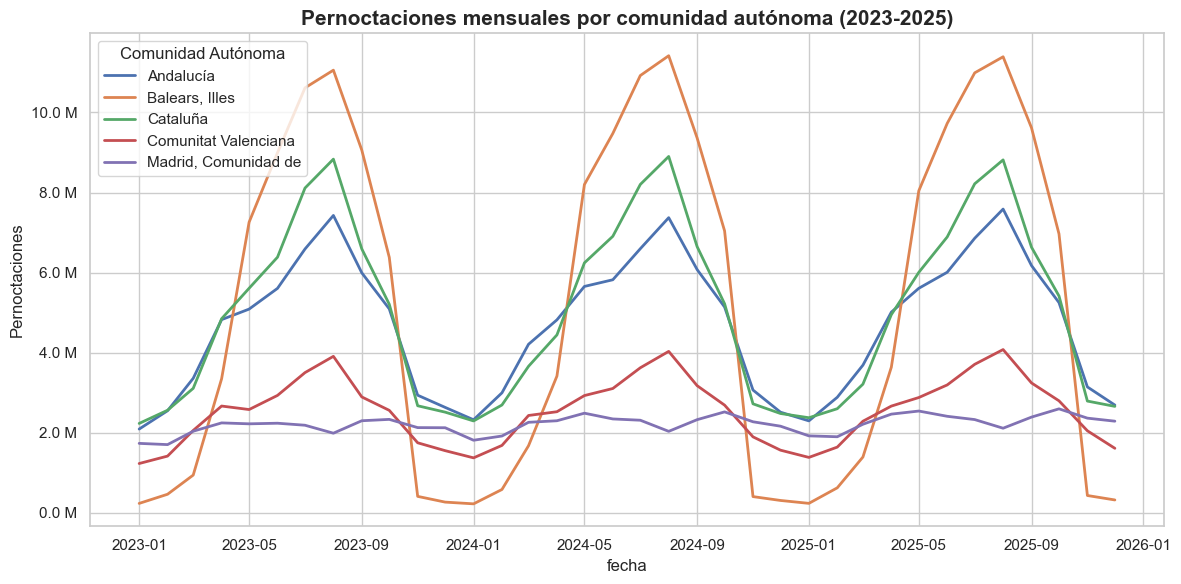

In [308]:
fig, ax = plt.subplots(figsize=(12,6))
for comunidad, grupo in serie_ccaa.groupby("Comunidad"):
    grupo = grupo.sort_values("fecha")
    ax.plot(
        grupo["fecha"],
        grupo["valor"],
        linewidth=2,
        label=comunidad
    )
ax.set_title(
    "Pernoctaciones mensuales por comunidad autónoma (2023-2025)",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("fecha")
ax.set_ylabel("Pernoctaciones")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x,_: f"{x/1e6:.1f} M"
    )
)

plt.legend(title="Comunidad Autónoma")

plt.tight_layout()

plt.show()

### Interpretación
La evolución mensual muestra un patrón  estacional en la mayoría de comunidades autónomas donde opera StaySpain. Illes Balears concentra el mayor volumen de demanda durante los meses de verano, mientras que Cataluña, Andalucía y Comunitat Valenciana también presentan incrementos importantes entre junio y septiembre. Madrid mantiene un comportamiento más estable durante todo el año. 

## 3.2 Patrón estacional medio

Para identificar el comportamiento estacional típico, se calcula la media mensual de las pernoctaciones entre 2023 y 2025. De este modo se obtiene un patrón representativo de cada comunidad autónoma.

In [309]:
estacionalidad_media = (
    serie_ccaa
    .groupby(
        ["Comunidad","Mes"]
    )["valor"]
    .mean()
    .reset_index()
)

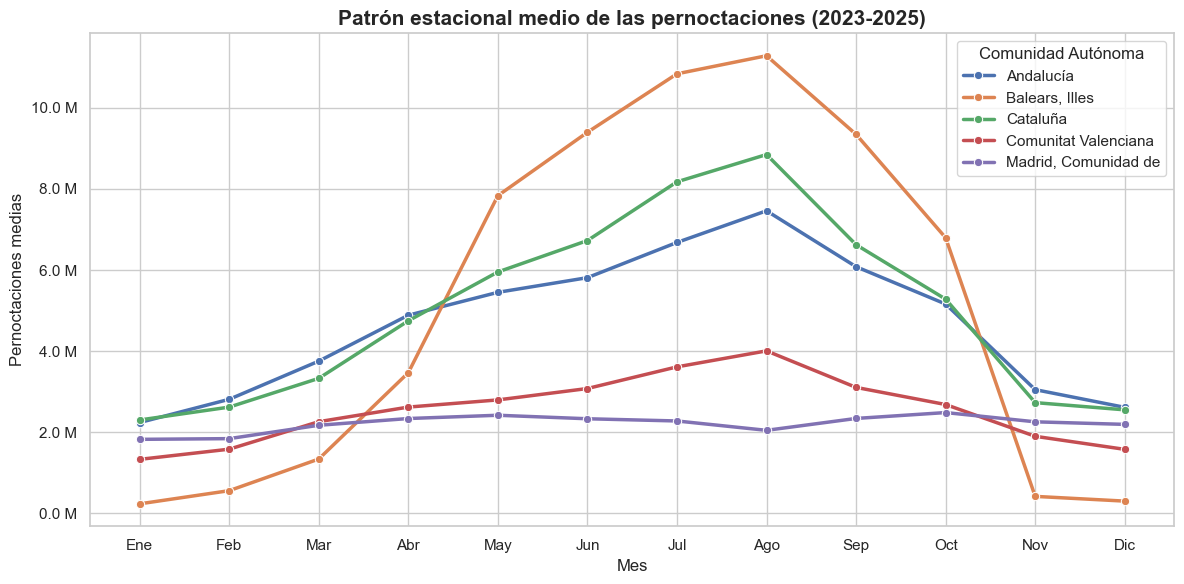

In [310]:
fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(
    data=estacionalidad_media,
    x="Mes",
    y="valor",
    hue="Comunidad",
    marker="o",
    linewidth=2.5,
    ax=ax
)

ax.set_title(
    "Patrón estacional medio de las pernoctaciones (2023-2025)",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Mes")
ax.set_ylabel("Pernoctaciones medias")
ax.set_xticks(range(1,13))
ax.set_xticklabels([
    "Ene","Feb","Mar","Abr","May","Jun",
    "Jul","Ago","Sep","Oct","Nov","Dic"
])
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x,_:f"{x/1e6:.1f} M"
    )
)
ax.legend(title="Comunidad Autónoma")
plt.tight_layout()
plt.show()

### Interpretación

Al promediar los tres años se observa con mayor claridad el patrón
estacional característico de cada comunidad autónoma.

Illes Balears presenta la mayor concentración de demanda durante los
meses de verano.

Andalucía, Cataluña y Comunitat Valenciana también muestran un fuerte
incremento de las pernoctaciones entre junio y septiembre.

Madrid presenta una evolución más estable a lo largo del año,
con un comportamiento diferente al resto de destinos turísticos.

## 3.3 Intensidad de la estacionalidad

Se representa la intensidad media de las pernoctaciones mediante un mapa
de calor para facilitar la identificación visual de los meses con mayor
demanda en cada comunidad autónoma.

In [311]:
heatmap = (
    serie_ccaa
    .groupby(
        ["Comunidad","Mes"]
    )["valor"]
    .mean()
    .unstack()
)
heatmap = heatmap.astype("float")

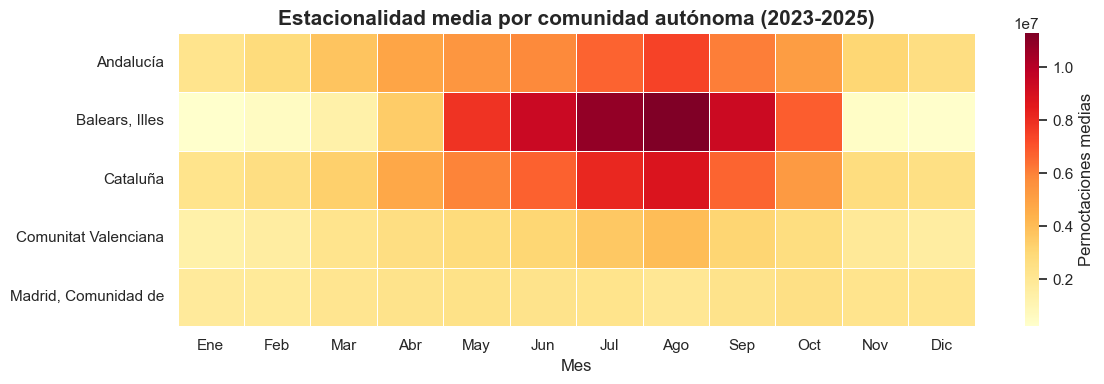

In [312]:
plt.figure(figsize=(12,4))

sns.heatmap(

    heatmap,

    cmap="YlOrRd",

    linewidths=.5,

    cbar_kws={

        "label":"Pernoctaciones medias"

    }

)

plt.title(

    "Estacionalidad media por comunidad autónoma (2023-2025)",

    fontsize=15,

    fontweight="bold"

)

plt.xlabel("Mes")

plt.ylabel("")

plt.xticks(

    np.arange(12)+0.5,

    [

        "Ene","Feb","Mar","Abr","May","Jun",

        "Jul","Ago","Sep","Oct","Nov","Dic"

    ]

)

plt.tight_layout()

plt.show()

### Interpretación

El mapa de calor facilita identificar visualmente los meses con mayor concentración de demanda. Cuanto más intenso es el color, mayor es el volumen medio de pernoctaciones. Se observa que Illes Balears concentra la demanda en julio y agosto, mientras que Madrid mantiene una distribución más homogénea durante el año.

## 3.4 Mes de mayor demanda

Con el objetivo de facilitar la interpretación para negocio, se identifica el
mes con el mayor número medio de pernoctaciones en cada comunidad autónoma.

Este indicador permite conocer cuándo se produce el pico de demanda turística
en los principales mercados donde opera StaySpain.

In [313]:
# Para cada comunidad autónoma se identifica el mes con mayor
# volumen medio de pernoctaciones durante el periodo 2023-2025.

mes_pico = (
    estacionalidad_media
    .loc[
        estacionalidad_media.groupby("Comunidad")["valor"].idxmax()
    ]
    .copy()
)
mes_pico

,Comunidad,Mes,valor
7,Andalucía,8,7.461796e+06
19,"Balears, Illes",8,1.128608e+07
31,Cataluña,8,8.849232e+06
43,Comunitat Valenciana,8,4.007302e+06
57,"Madrid, Comunidad de",10,2.485764e+06


In [314]:
# Convertir el número de mes a nombre

MESES = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
}
mes_pico["Mes pico"] = mes_pico["Mes"].map(MESES)


In [315]:
# Pasar las pernoctaciones a millones

mes_pico["Pernoctaciones medias (millones)"] = (
    mes_pico["valor"] / 1_000_000
).round(2)

In [316]:
# Tabla resumen

tabla_resumen = (
    mes_pico[
        ["Comunidad",
        "Mes pico",
        "Pernoctaciones medias (millones)"]]
    .sort_values(
        "Pernoctaciones medias (millones)",
        ascending=False
    )
    .reset_index(drop=True)
)

tabla_resumen

,Comunidad,Mes pico,Pernoctaciones medias (millones)
0,"Balears, Illes",Agosto,11.29
1,Cataluña,Agosto,8.85
2,Andalucía,Agosto,7.46
3,Comunitat Valenciana,Agosto,4.01
4,"Madrid, Comunidad de",Octubre,2.49


La mayoría de comunidades alcanzan su máximo de demanda en agosto. Madrid constituye la principal excepción, registrando su mayor volumen de pernoctaciones en octubre.

### Interpretación

La mayoría de comunidades presentan su máximo volumen de pernoctaciones durante
los meses estivales.

Illes Balears registra el mayor pico de demanda, seguida de Cataluña y
Andalucía, mientras que Madrid muestra una distribución más equilibrada a lo
largo del año.

## 3.5. Validación de la estabilidad estacional (Spearman)

Para comprobar si el patrón estacional se mantiene a lo largo del tiempo, se compara el comportamiento mensual de las pernoctaciones entre los años 2023, 2024 y 2025 mediante la correlación de Spearman.

Una correlación elevada indica que el orden de los meses según su nivel de demanda es similar entre los distintos años, lo que sugiere un patrón estacional estable.

In [317]:
serie_spearman = (
    serie_ccaa
    .groupby(
        [serie_ccaa["fecha"].dt.year.rename("Año"), "Mes"]
    )["valor"]
    .sum()
    .reset_index()
)

tabla = (
    serie_spearman
    .pivot(
        index="Mes",
        columns="Año",
        values="valor"
    )
)

corr = tabla.corr(method="spearman")

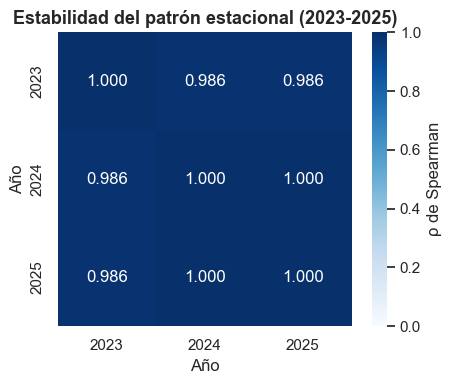

In [318]:
plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label":"ρ de Spearman"}
)

plt.title(
    "Estabilidad del patrón estacional (2023-2025)",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Los coeficientes de Spearman obtenidos entre los años 2023, 2024 y 2025 son superiores a 0,98, lo que indica una asociación muy fuerte entre los patrones mensuales de demanda.

Esto significa que los meses con mayor y menor volumen de pernoctaciones se repiten prácticamente en el mismo orden cada año, confirmando que la estacionalidad observada constituye un patrón estable y no un comportamiento puntual.

En consecuencia, el periodo 2023-2025 puede utilizarse como una referencia representativa para caracterizar la demanda turística en los destinos donde opera StaySpain.

# 4. ¿Quién impulsa la estacionalidad?

Hasta este punto se ha analizado la evolución global de las pernoctaciones. Sin embargo, la demanda turística puede presentar comportamientos diferentes según el lugar de residencia de los viajeros.

En este apartado se compara la evolución mensual de las pernoctaciones de los residentes en España y de los residentes en el extranjero con el objetivo de identificar qué grupo impulsa la estacionalidad y en qué momentos del año se concentra su demanda.

In [319]:
# Residentes en España vs Extranjero

demanda_residencia = (
    df_2074[
        (df_2074["nivel_geo"] == "ccaa")
        &
        (df_2074["geo"].isin(ccaa_interes))
        &
        (df_2074["metrica"] == "pernoctaciones")
        &
        (df_2074["categoria"].isin([
            "Residentes en España",
            "Residentes en el Extranjero"
        ]))
        &
        (df_2074["fecha"].between(PERIODO_INICIO, PERIODO_FIN))
    ]
    .groupby(
        ["fecha","categoria"],
        as_index=False
    )["valor"]
    .sum()
)

demanda_residencia["Mes"] = (
    demanda_residencia["fecha"].dt.month
)

### Evolución mensual de las pernoctaciones según la residencia del viajero

Se representa la evolución mensual de las pernoctaciones distinguiendo entre residentes en España y residentes en el extranjero para identificar posibles diferencias en su comportamiento estacional.

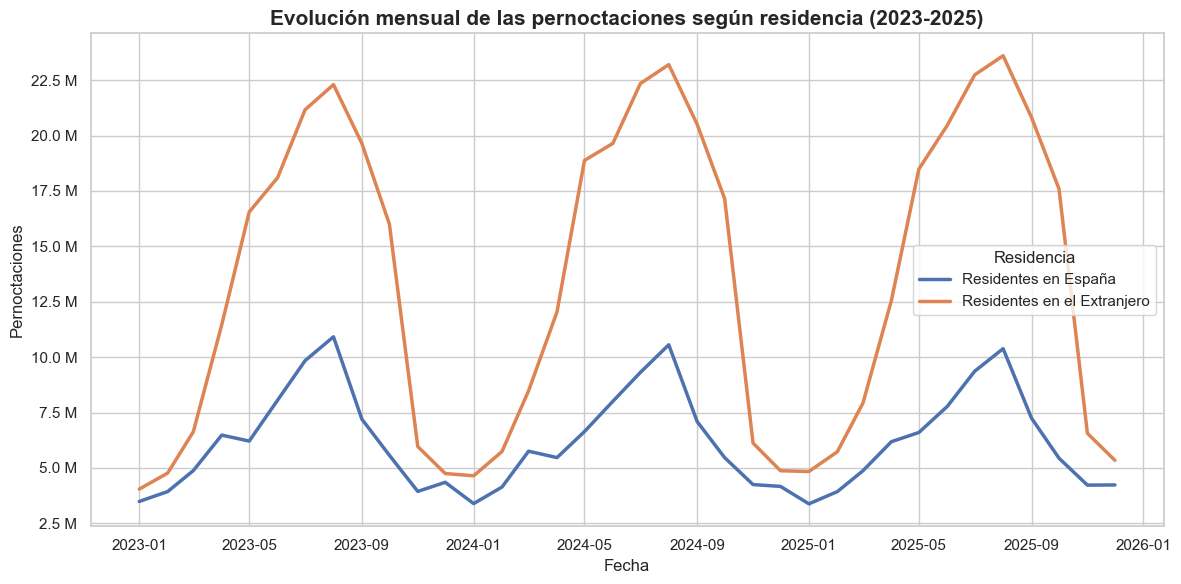

In [320]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=demanda_residencia,
    x="fecha",
    y="valor",
    hue="categoria",
    linewidth=2.5
)

plt.title(
    "Evolución mensual de las pernoctaciones según residencia (2023-2025)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Fecha")
plt.ylabel("Pernoctaciones")

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x,_: f"{x/1e6:.1f} M"
    )
)

plt.legend(title="Residencia")

plt.tight_layout()
plt.show()

Los residentes en el extranjero generan un mayor volumen de pernoctaciones durante todo el año y son los principales responsables del incremento de la demanda en los meses de verano. Los residentes en España también presentan un patrón estacional, aunque con una intensidad considerablemente menor.

## 4.2 Patrón estacional medio según residencia
Para facilitar la comparación entre ambos grupos, se calcula la media de las pernoctaciones de cada mes durante el periodo 2023-2025.

In [321]:
patron_residencia = (
    demanda_residencia
    .groupby(
        ["categoria","Mes"],
        as_index=False
    )
    .agg(
        pernoctaciones_media=("valor","mean")
    )
)

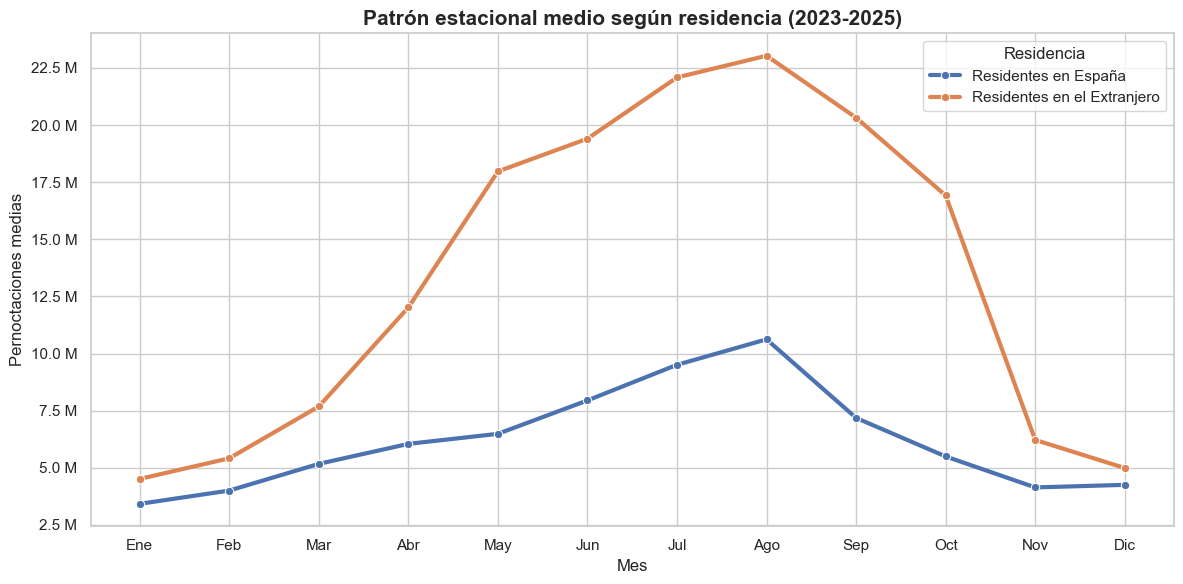

In [322]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=patron_residencia,
    x="Mes",
    y="pernoctaciones_media",
    hue="categoria",
    marker="o",
    linewidth=3
)

plt.title(
    "Patrón estacional medio según residencia (2023-2025)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mes")
plt.ylabel("Pernoctaciones medias")

plt.xticks(
    range(1,13),
    [
        "Ene","Feb","Mar","Abr","May","Jun",
        "Jul","Ago","Sep","Oct","Nov","Dic"
    ]
)

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x,_: f"{x/1e6:.1f} M"
    )
)

plt.legend(title="Residencia")

plt.tight_layout()
plt.show()

Interpretación

Al promediar los tres años se observa que ambos grupos concentran la demanda entre mayo y septiembre. Sin embargo, la estacionalidad es mucho más intensa entre los residentes en el extranjero, cuyo máximo se alcanza en agosto, mientras que la demanda nacional presenta una distribución más moderada.

## 4.3 ¿Quién domina la demanda en cada mes?

## Peso relativo de residentes nacionales y extranjeros
Además del volumen absoluto de pernoctaciones, se analiza el peso relativo de cada grupo para identificar qué tipo de viajero predomina en cada momento del año.

In [323]:
porcentaje = (
    patron_residencia
    .pivot(
        index="Mes",
        columns="categoria",
        values="pernoctaciones_media"))

porcentaje = (
    porcentaje
    .div(
        porcentaje.sum(axis=1),
        axis=0)*100)

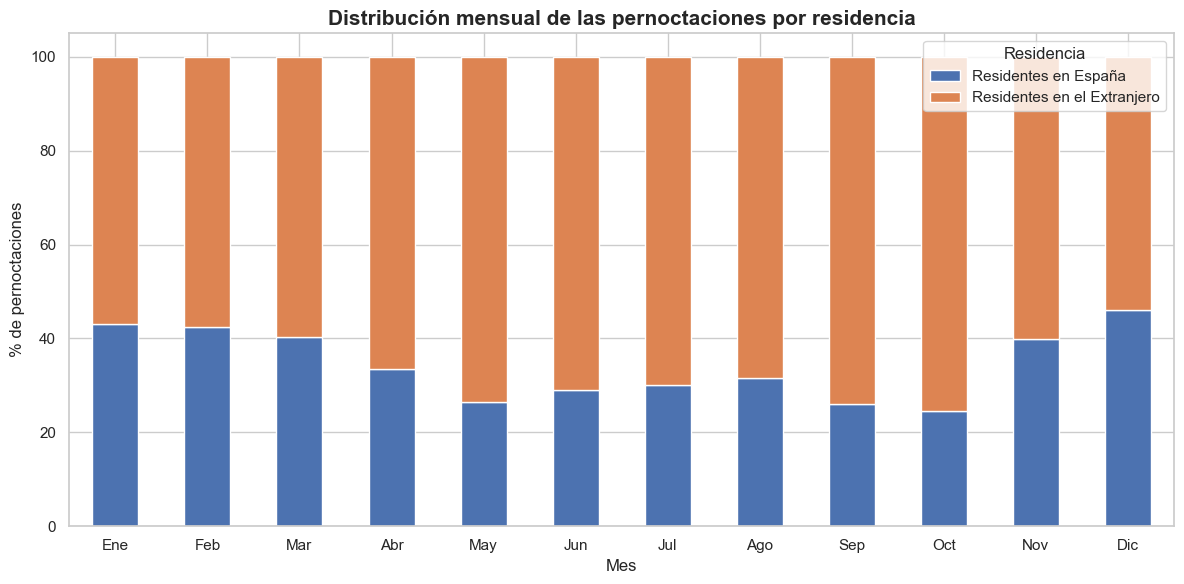

In [324]:
porcentaje.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6))

plt.title(
    "Distribución mensual de las pernoctaciones por residencia",
    fontsize=15,
    fontweight="bold")

plt.ylabel("% de pernoctaciones")

plt.xlabel("Mes")

plt.xticks(
    range(12),
    [
        "Ene","Feb","Mar","Abr","May","Jun",
        "Jul","Ago","Sep","Oct","Nov","Dic"
    ],
    rotation=0)

plt.legend(title="Residencia")

plt.tight_layout()

plt.show()

Interpretación

Los residentes en el extranjero representan la mayor parte de las pernoctaciones durante todo el año, especialmente entre mayo y octubre. En cambio, el peso relativo de los residentes en España aumenta durante los meses de invierno, cuando la demanda internacional disminuye.

## 4.4 Mes de mayor demanda por residencia

Tabala resumen,  mes de mayor demanda por residencia

In [325]:
mes_pico = (
    patron_residencia
    .loc[
        patron_residencia.groupby("categoria")["pernoctaciones_media"].idxmax()
    ]
    .copy())

MESES = {
    1:"Enero",2:"Febrero",3:"Marzo",4:"Abril",
    5:"Mayo",6:"Junio",7:"Julio",8:"Agosto",
    9:"Septiembre",10:"Octubre",11:"Noviembre",12:"Diciembre"}

mes_pico["Mes pico"] = mes_pico["Mes"].map(MESES)

mes_pico["Pernoctaciones medias (millones)"] = (
    mes_pico["pernoctaciones_media"]/1_000_000).round(2)

tabla_resumen = (
    mes_pico[
        [
            "categoria",
            "Mes pico",
            "Pernoctaciones medias (millones)"]]
    .rename(columns={
        "categoria":"Residencia"}))

tabla_resumen

,Residencia,Mes pico,Pernoctaciones medias (millones)
7,Residentes en España,Agosto,10.62
19,Residentes en el Extranjero,Agosto,23.03


Tanto los residentes nacionales como los residentes en el extranjero alcanzan su máximo volumen de pernoctaciones en agosto. No obstante, la intensidad del pico es considerablemente mayor entre los visitantes internacionales, lo que confirma que son el principal motor de la estacionalidad turística.

# 5. Perfil del viajero nacional: ¿de dónde viene y cuándo viaja?

Tras analizar la estacionalidad general y comprobar las diferencias entre residentes nacionales y extranjeros, este apartado se centra exclusivamente en el turismo nacional.

El objetivo es identificar las principales comunidades autónomas emisoras de cada destino donde opera StaySpain y analizar tanto su importancia relativa como el momento del año en el que realizan sus viajes.

Durante el proceso de preparación de datos se incorporó la variable valor_estimado_origen, que permite aproximar el número absoluto de viajeros nacionales a partir de los porcentajes publicados por la EOH.

## 5.1 Preparación del subconjunto de trabajo

Se calcula el porcentaje medio de viajeros procedentes de cada comunidad autónoma durante el periodo 2023-2025.

Utilizar el promedio de los tres años permite obtener una visión representativa de los principales mercados emisores, evitando que un único año excepcional condicione los resultados.

In [326]:
# Tabla 2069 - Procedencia del turismo nacional

procedencia = (
    df_2069[
        (df_2069["tabla"] == 2069)
        & (df_2069["fecha"].between(PERIODO_INICIO, PERIODO_FIN))
        & (df_2069["metrica"] == "viajeros")
        & (df_2069["categoria"] != "Total")
        & (df_2069["mercados_relacionados"].notna())
    ]
    .copy()
)

# Nombre del destino
procedencia["Destino"] = procedencia["mercados_relacionados"]

# Unificamos Mallorca y Menorca
procedencia["Destino"] = procedencia["Destino"].replace({
    "Mallorca | Menorca": "Mallorca y Menorca"
})

print(f"Registros: {len(procedencia):,}")

Registros: 4,788


Los registros contienen información mensual para cada combinación de:

- destino de StaySpain,
- comunidad autónoma de procedencia,
- porcentaje de viajeros nacionales (`valor`),
- estimación del número absoluto de viajeros (`valor_estimado_origen`).

Este subconjunto constituye la base para el resto del análisis.

## 5.2 Principales mercados emisores nacionales

Como primera aproximación se calcula la participación media de cada comunidad
autónoma durante el periodo 2023-2025.

Al utilizar el promedio de los tres años se obtiene una visión más estable del
peso relativo de cada mercado emisor, evitando que meses excepcionales
distorsionen los resultados.

In [327]:
participacion = (
    procedencia
    .groupby(
        ["Destino", "categoria"],
        as_index=False
    )["valor"]
    .mean()
)

participacion.rename(
    columns={
        "categoria": "Comunidad",
        "valor": "Porcentaje medio"
    },
    inplace=True
)

El siguiente mapa de calor resume qué comunidades autónomas aportan una mayor proporción de viajeros nacionales a cada destino de StaySpain.

In [328]:
# Tabla destino × comunidad

tabla_heatmap = (
    participacion
    .pivot(
        index="Comunidad",
        columns="Destino",
        values="Porcentaje medio"))

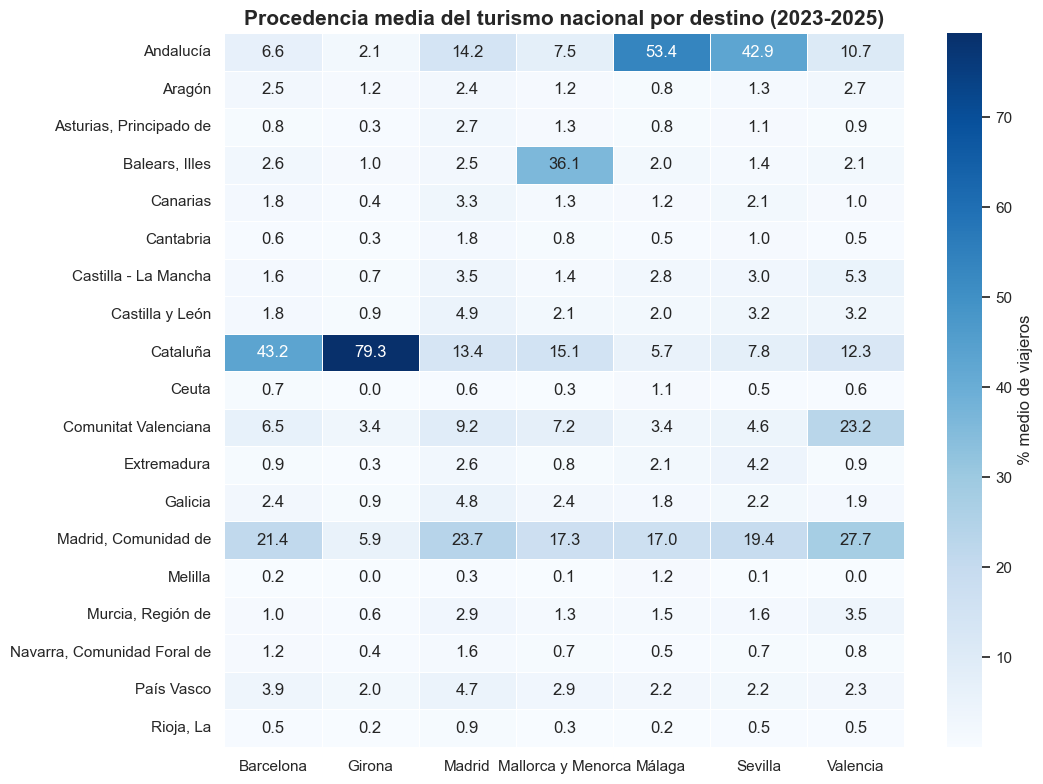

In [329]:
plt.figure(figsize=(11,8))

sns.heatmap(
    tabla_heatmap,
    cmap="Blues",
    annot=True,
    fmt=".1f",
    linewidths=.5,
    cbar_kws={"label":"% medio de viajeros"}
)

plt.title(
    "Procedencia media del turismo nacional por destino (2023-2025)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()

Los resultados muestran un claro efecto de proximidad geográfica.

Cataluña constituye el principal mercado emisor de Barcelona y Girona.

Andalucía domina claramente Málaga y Sevilla.

Madrid destaca como uno de los principales mercados emisores en prácticamente todos los destinos.

Mallorca y Menorca presentan una distribución más diversificada, aunque Baleares continúa siendo el principal mercado nacional.

Para facilitar la interpretación se representan únicamente las cinco comunidades autónomas con mayor participación media en cada destino.

In [330]:
top5 = (
    participacion
    .sort_values(
        ["Destino", "Porcentaje medio"],
        ascending=[True, False]
    )
    .groupby("Destino")
    .head(5))

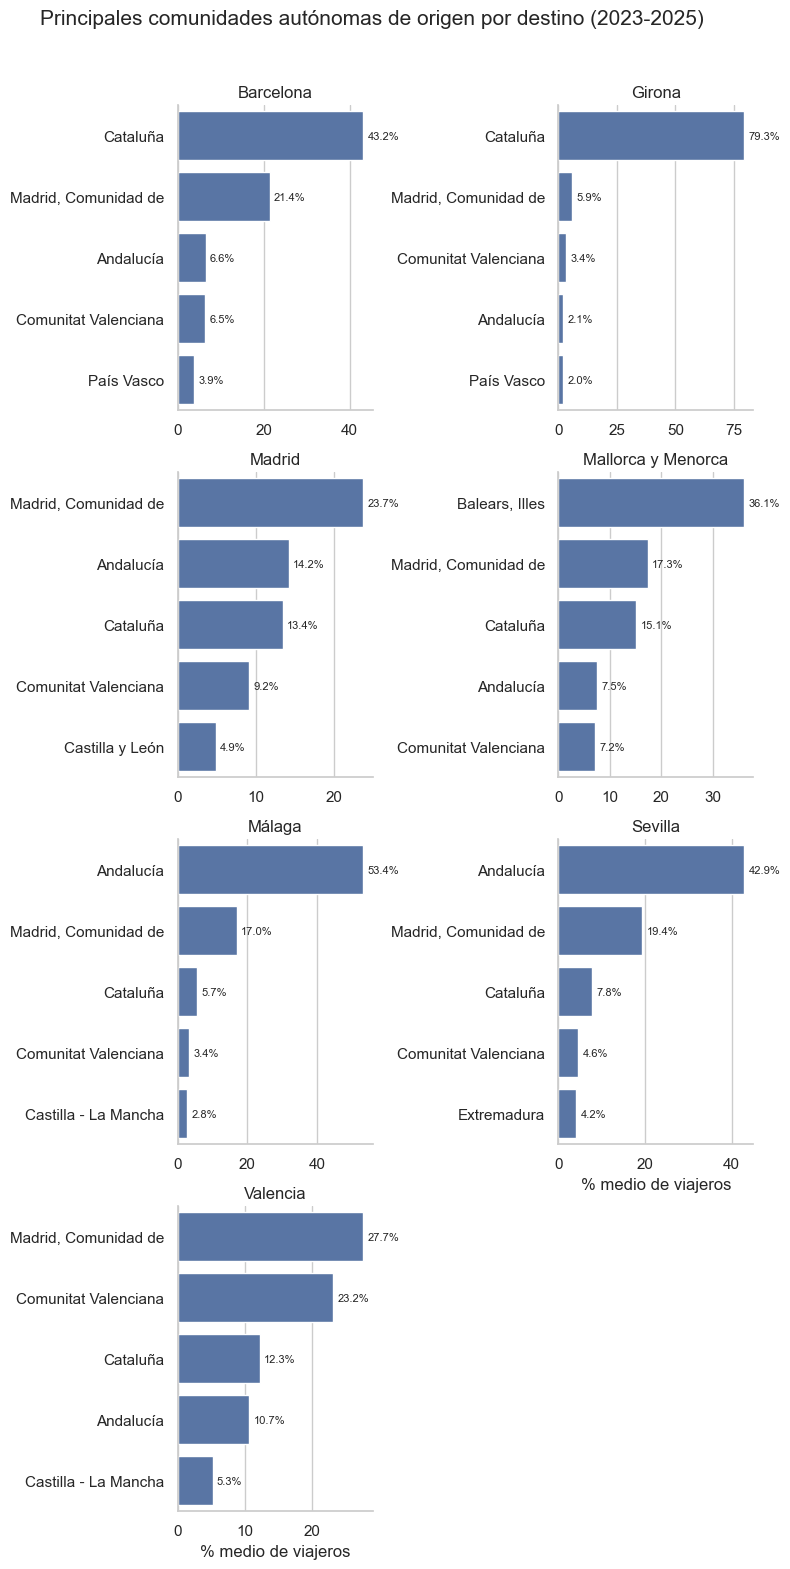

In [331]:
# Top 5 comunidades autónomas por destino
# de que comunidades vienen?

g = sns.FacetGrid(
    top5,
    col="Destino",
    col_wrap=2,
    height=4,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.barplot,
    x="Porcentaje medio",
    y="Comunidad",
    color="#4C72B0"
)

g.set_titles("{col_name}")
g.set_axis_labels("% medio de viajeros", "")

for ax in g.axes.flat:

    for container in ax.containers:

        ax.bar_label(
            container,
            fmt="%.1f%%",
            fontsize=8,
            padding=3
        )

plt.subplots_adjust(top=0.92)

g.fig.suptitle(
    "Principales comunidades autónomas de origen por destino (2023-2025)",
    fontsize=15
)

plt.show()



### Primera lectura
Los resultados muestran un claro efecto de proximidad geográfica.

En la mayoría de destinos, la propia comunidad autónoma constituye el principal mercado emisor nacional.

Madrid aparece como uno de los mercados emisores más relevantes en prácticamente todos los destinos, mientras que Cataluña concentra gran parte de la demanda de Barcelona y Girona y Andalucía domina claramente Málaga y Sevilla.

No obstante, esta distribución media no permite conocer cuándo viajan estos mercados a lo largo del año, por lo que en el siguiente apartado se analiza su evolución mensual.

## 5.3 ¿Cuándo viajan los principales mercados nacionales?

Conocer qué comunidades autónomas aportan un mayor volumen de viajeros resulta
útil para identificar los principales mercados emisores. Sin embargo, desde una
perspectiva de negocio también es importante analizar **cuándo** se producen
esas visitas.

Para ello se estudia la evolución mensual del número estimado de viajeros
(`valor_estimado_origen`) procedentes de las principales comunidades autónomas
de cada destino.

Este análisis permite identificar si cada mercado mantiene una demanda estable
a lo largo del año o si concentra su actividad en determinados meses,
contribuyendo así a la estacionalidad del destino.

In [332]:
# Top 5 comunidades por volumen de viajeros estimados

top5_origen = (
    procedencia
    .groupby(
        ["Destino", "categoria"],
        as_index=False
    )["valor_estimado_origen"]
    .sum()
)

top5_origen = (
    top5_origen
    .sort_values(
        ["Destino", "valor_estimado_origen"],
        ascending=[True, False]
    )
    .groupby("Destino")
    .head(5)
)

In [333]:
procedencia["valor_estimado_origen"] = (
    procedencia["valor_estimado_origen"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)

In [334]:
# Nos quedamos únicamente con esos mercados principales

serie_top5 = procedencia.merge(
    top5_origen[["Destino", "categoria"]],
    on=["Destino", "categoria"],
    how="inner"
)

In [335]:
serie_media = (
    serie_top5
    .groupby(
        ["Destino","categoria","mes","mes_nombre_corto"],
        as_index=False
    )["valor_estimado_origen"]
    .mean()
)

In [336]:
orden = [
    "Ene","Feb","Mar","Abr","May","Jun",
    "Jul","Ago","Sep","Oct","Nov","Dic"
]

serie_media["mes_nombre_corto"] = pd.Categorical(
    serie_media["mes_nombre_corto"],
    categories=orden,
    ordered=True
)

## Evolución mensual de los principales mercados emisores
Se representa la evolución mensual del número estimado de viajeros procedentes de las cinco principales comunidades autónomas de cada destino.

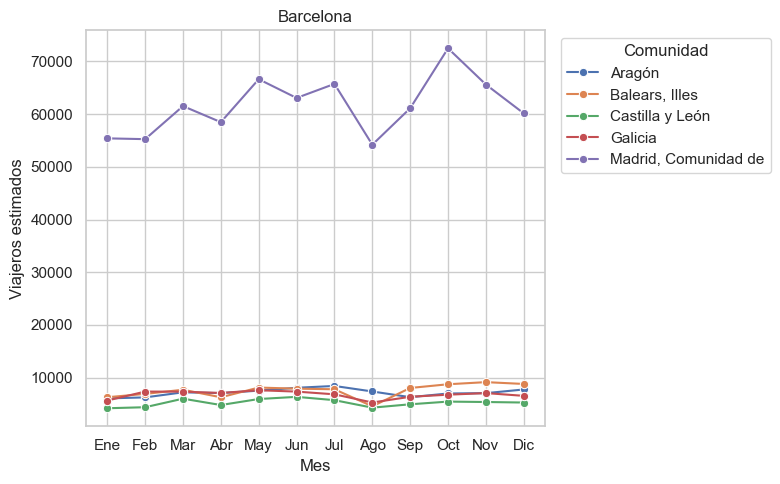

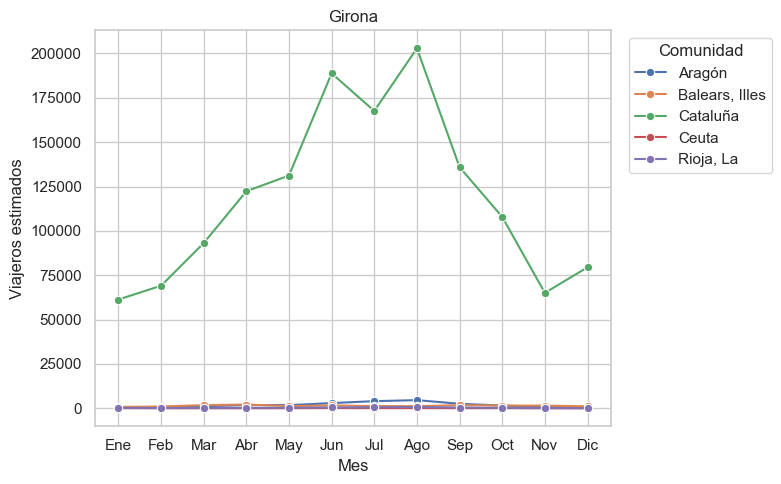

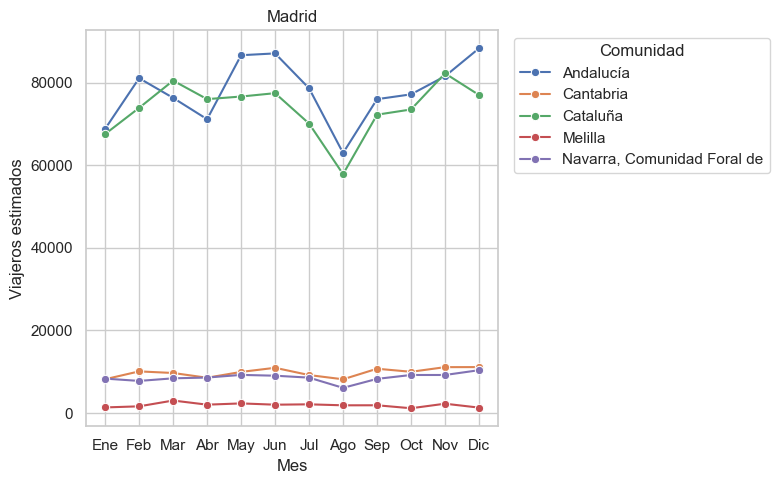

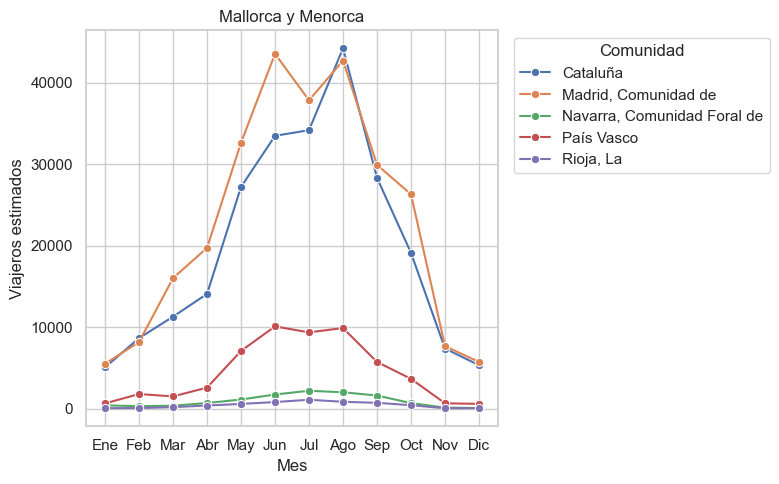

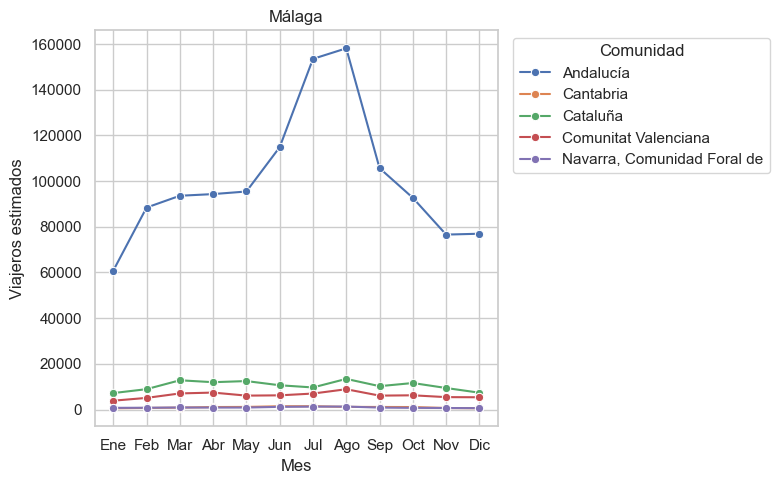

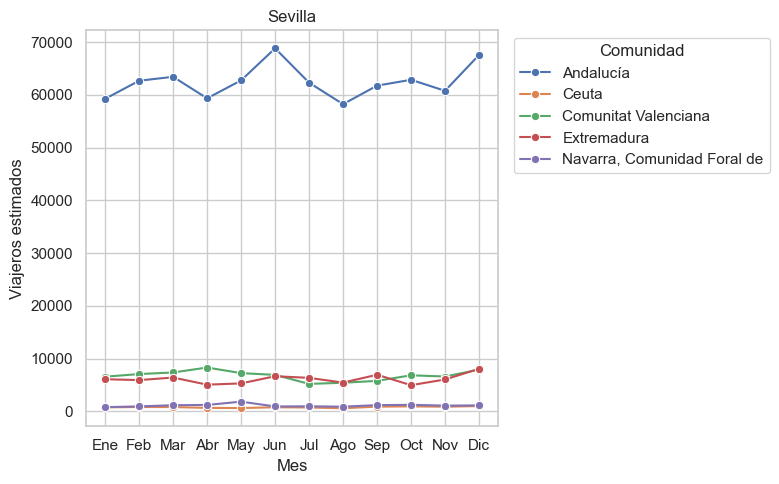

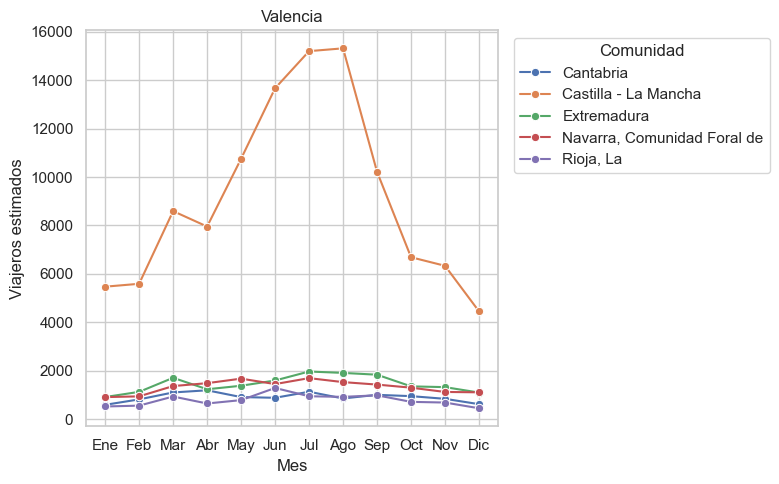

In [337]:
destinos = serie_media["Destino"].unique()

for destino in destinos:

    datos = serie_media[serie_media["Destino"] == destino]

    plt.figure(figsize=(8, 5))

    sns.lineplot(
        data=datos,
        x="mes_nombre_corto",
        y="valor_estimado_origen",
        hue="categoria",
        marker="o"
    )

    plt.title(f"{destino}")
    plt.xlabel("Mes")
    plt.ylabel("Viajeros estimados")

    plt.legend(
        title="Comunidad",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

### Interpretación

Los resultados muestran que la demanda nacional presenta patrones diferentes según el destino.

En los destinos vacacionales (Mallorca y Menorca, Girona y Málaga) los principales mercados emisores concentran gran parte de sus viajes entre mayo y septiembre.

En cambio, Barcelona, Madrid, Sevilla y Valencia presentan una distribución más estable durante el año, con una menor dependencia de la temporada estival.

Estos resultados permiten identificar no solo qué comunidades generan más viajeros, sino también en qué momento del año realizan sus desplazamientos.

A continuación se representa la evolución mensual de los cinco principales
mercados emisores de cada destino.

## 5.5. Validación de la estabilidad del turismo nacional (Spearman)

Para comprobar si el patrón mensual del turismo nacional se mantiene estable a lo largo del tiempo, se compara el comportamiento mensual del número estimado de viajeros nacionales entre los años 2023, 2024 y 2025 mediante la correlación de Spearman.

Una correlación elevada indica que el orden de los meses según el volumen de viajeros nacionales es muy similar entre los distintos años, lo que confirma que la estacionalidad observada responde a un patrón recurrente y no a un comportamiento puntual.

In [338]:
# Serie mensual de viajeros nacionales por año

serie_spearman = (
    procedencia
    .groupby(
        [
            procedencia["fecha"].dt.year.rename("Año"),
            "mes"
        ]
    )["valor_estimado_origen"]
    .sum()
    .reset_index()
)

serie_spearman.head()

,Año,mes,valor_estimado_origen
0,2023,1,1.278193e+06
1,2023,2,1.357878e+06
2,2023,3,1.614517e+06
3,2023,4,1.740860e+06
4,2023,5,1.779665e+06


In [339]:
# Tabla Mes × Año

tabla = (
    serie_spearman
    .pivot(
        index="mes",
        columns="Año",
        values="valor_estimado_origen"
    )
)

tabla

Año,2023,2024,2025
mes,,,
1,1.278193e+06,1.214169e+06,1.181719e+06
2,1.357878e+06,1.386743e+06,1.326197e+06
3,1.614517e+06,1.660832e+06,1.458898e+06
4,1.740860e+06,1.517347e+06,1.551331e+06
5,1.779665e+06,1.773410e+06,1.697611e+06
6,2.053542e+06,1.972424e+06,1.854211e+06
7,1.994984e+06,1.880431e+06,1.868455e+06
8,1.908609e+06,1.840707e+06,1.806388e+06
9,1.747419e+06,1.644810e+06,1.677664e+06


In [340]:
# Correlación de Spearman

corr = tabla.corr(method="spearman")

corr

Año,2023,2024,2025
Año,,,
2023,1.000000,0.944056,0.965035
2024,0.944056,1.000000,0.881119
2025,0.965035,0.881119,1.000000


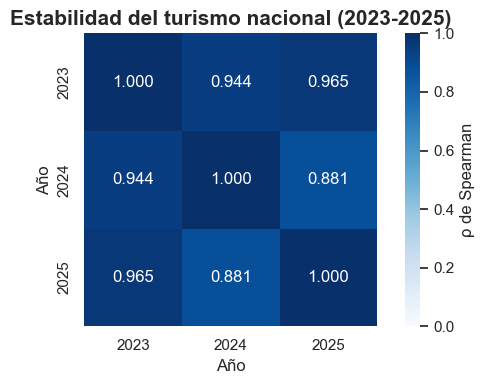

In [341]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={
        "label":"ρ de Spearman"
    }
)

plt.title(
    "Estabilidad del turismo nacional (2023-2025)",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Interpretación

Las correlaciones de Spearman obtenidas entre los años 2023, 2024 y 2025 son muy elevadas, lo que indica que el patrón mensual del turismo nacional se mantiene estable a lo largo del periodo analizado.

Esto significa que los meses con mayor y menor volumen de viajeros nacionales se repiten prácticamente en el mismo orden cada año, confirmando que la estacionalidad observada responde a un comportamiento recurrente y no a circunstancias puntuales de un año concreto.

En consecuencia, el periodo 2023-2025 constituye una base representativa para analizar el perfil del viajero nacional y estudiar cómo varía la procedencia de la demanda entre los distintos destinos donde opera StaySpain.

## 6. ¿Existen diferencias entre destinos?


Una vez analizada la estacionalidad general y el perfil del viajero, este apartado compara el comportamiento estacional de los distintos destinos donde opera StaySpain para identificar diferencias en la intensidad y duración de la demanda.

### 6.1. Comparación entre ciudades

Se comparan Barcelona, Madrid, Málaga, Sevilla y Valencia mediante las pernoctaciones medias mensuales del periodo 2023-2025.

In [342]:
#patron de estacionalidad 
ciudades_media = (

    serie_ciudades.groupby(
        ["Ciudad","Mes"]
    )["valor"].mean().reset_index())

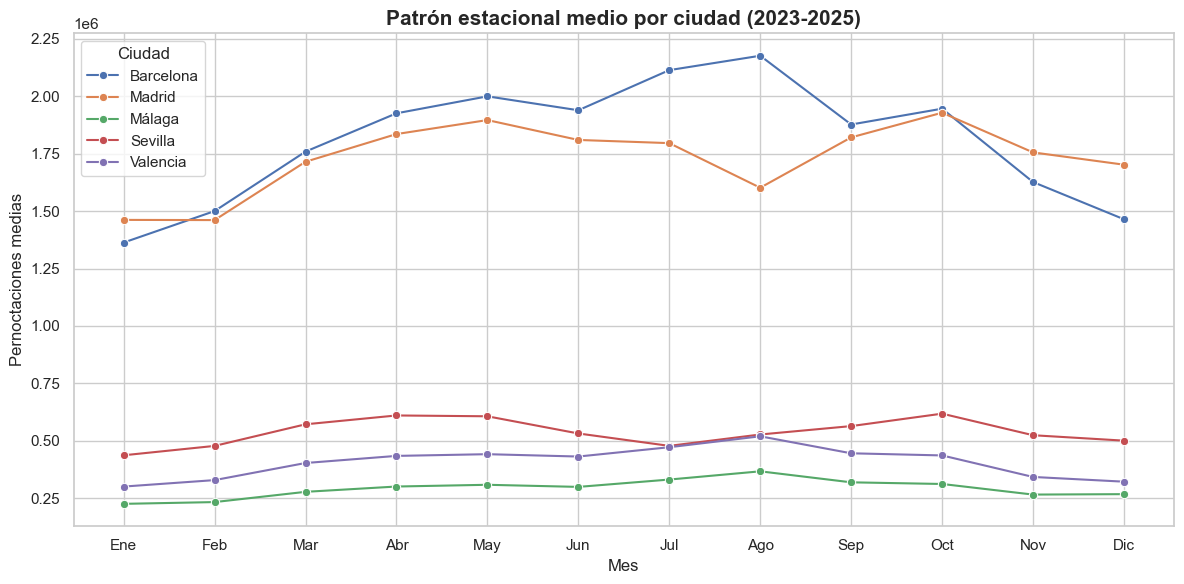

In [343]:
plt.figure(figsize=(12,6))

sns.lineplot(

    data=ciudades_media,
    x="Mes",
    y="valor",
    hue="Ciudad",
    marker="o"
)

plt.title(
    "Patrón estacional medio por ciudad (2023-2025)",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(
    range(1,13),
    [
        "Ene","Feb","Mar","Abr","May","Jun",
        "Jul","Ago","Sep","Oct","Nov","Dic"
    ]
)

plt.xlabel("Mes")
plt.ylabel("Pernoctaciones medias")
plt.tight_layout()

plt.show()

### Interpretación

- Barcelona presenta un incremento progresivo hasta verano.
- Madrid mantiene la distribución más estable.
- Málaga y Sevilla muestran una estacionalidad moderada.
- Valencia presenta un comportamiento intermedio.

In [344]:
# Tabla resumen
mes_pico_ciudad = (

    ciudades_media.loc[
        ciudades_media
        .groupby("Ciudad")["valor"]
        .idxmax()
]

)

mes_pico_ciudad

,Ciudad,Mes,valor
7,Barcelona,8,2.176613e+06
21,Madrid,10,1.928487e+06
31,Málaga,8,3.667377e+05
45,Sevilla,10,6.178983e+05
55,Valencia,8,5.192587e+05


## 6.2. Comparación de la estacionalidad de los principales destinos turísticos
Para los destinos insulares y de costa se comparan Girona, Mallorca y Menorca.

Patrón estacional

In [345]:
zonas_media = (
    serie_zonas
    .groupby(
        ["Destino", "Mes"]
    )["valor"]
    .mean()
    .reset_index()
)

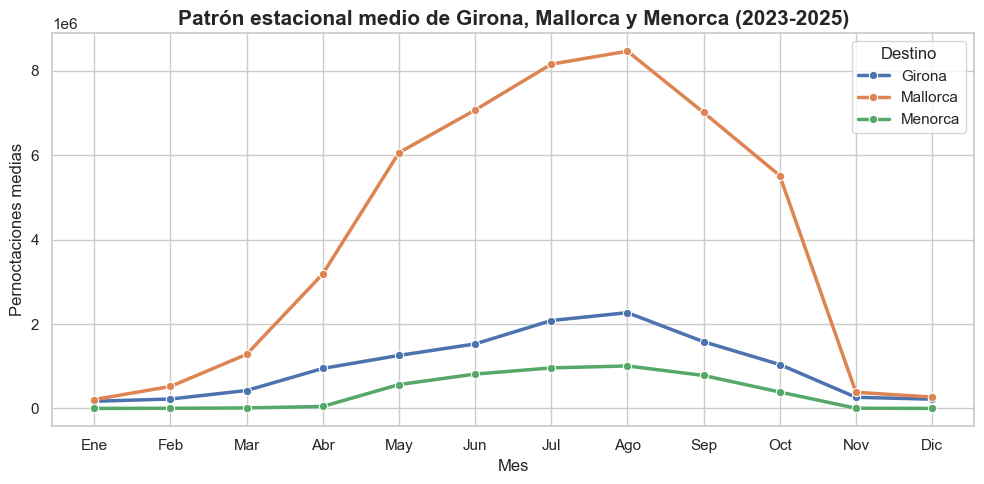

In [346]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=zonas_media,
    x="Mes",
    y="valor",
    hue="Destino",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Patrón estacional medio de Girona, Mallorca y Menorca (2023-2025)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mes")
plt.ylabel("Pernoctaciones medias")

plt.xticks(
    range(1,13),
    ["Ene","Feb","Mar","Abr","May","Jun",
     "Jul","Ago","Sep","Oct","Nov","Dic"]
)

plt.tight_layout()
plt.show()

### Interpretación

- Mallorca presenta la mayor intensidad estacional.
- Girona concentra la demanda entre mayo y septiembre.
- Menorca muestra la temporada más corta.

## 6.3 Intensidad relativa de la estacionalidad

¿En qué meses la demanda está por encima o por debajo de lo habitual en cada destino?
como los destinos tienen volúmenes de demanda muy diferentes, se utiliza un índice estacional donde la media anual de cada destino equivale a 100. Esto permite comparar la intensidad de la estacionalidad independientemente del tamaño del mercado.:

>100 = demanda media anual del destino.

>100 = demanda superior a la media.

><100 = demanda inferior a la media.

* primero se hara un Grafico que contenga las ciudades principales de Stayspain y, posteriormente, una que incluya las 8 ciudades donde stayspain tiene alojamientos. 

In [347]:
# Preparar datos

demanda_destinos = pd.concat(
    [
        serie_ciudades.rename(columns={"Ciudad": "Destino"})[
            ["Destino", "Mes", "valor"]
        ],
        serie_zonas[
            ["Destino", "Mes", "valor"]]],
    ignore_index=True
)

demanda_media = (
    demanda_destinos
    .groupby(["Destino", "Mes"], as_index=False)
    .agg(
        demanda_media=("valor", "mean")
    ))

# Índice estacional
# 100 = media anual del destino

demanda_media["indice_estacional"] = (
    demanda_media["demanda_media"]
    /
    demanda_media.groupby("Destino")["demanda_media"].transform("mean")) * 100


# Destinos representativos

destinos_principales = [
    "Barcelona",
    "Madrid",
    "Girona",
    "Mallorca"]

grafico = demanda_media[
    demanda_media["Destino"].isin(destinos_principales)]

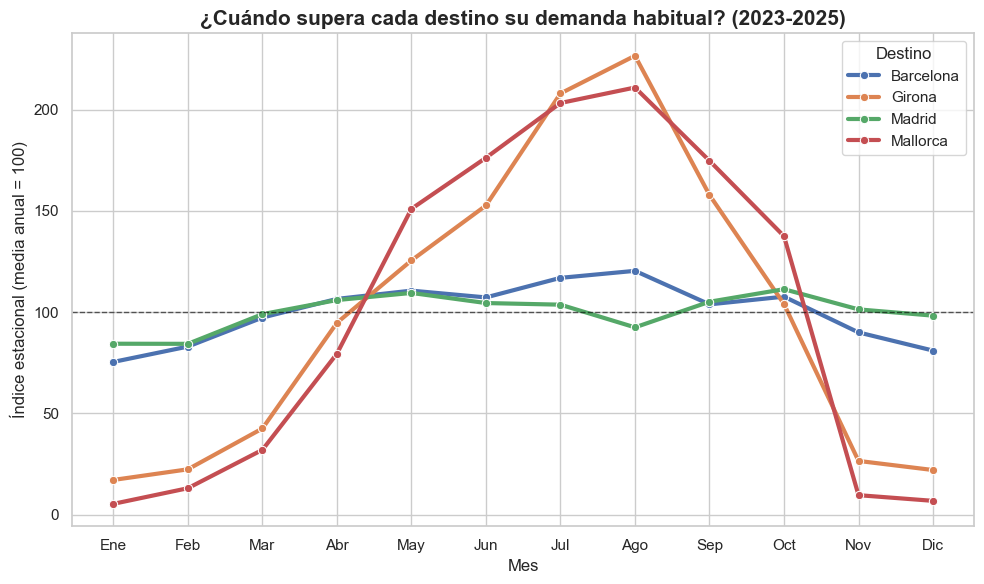

In [348]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=grafico,
    x="Mes",
    y="indice_estacional",
    hue="Destino",
    marker="o",
    linewidth=3
)

plt.axhline(
    100,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

plt.title(
    "¿Cuándo supera cada destino su demanda habitual? (2023-2025)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mes")
plt.ylabel("Índice estacional (media anual = 100)")

plt.xticks(
    range(1,13),
    [
        "Ene","Feb","Mar","Abr","May","Jun",
        "Jul","Ago","Sep","Oct","Nov","Dic"
    ]
)

plt.legend(title="Destino")

plt.tight_layout()
plt.show()

Para comparar la estacionalidad entre destinos con volúmenes de demanda muy diferentes, se calcula un índice estacional a partir de las pernoctaciones medias mensuales de la EOH (2023-2025). Cada destino se normaliza respecto a su propia media anual (100), lo que permite identificar los meses en los que la demanda se sitúa por encima o por debajo de su comportamiento habitual y comparar los patrones estacionales entre todos los mercados de StaySpain.

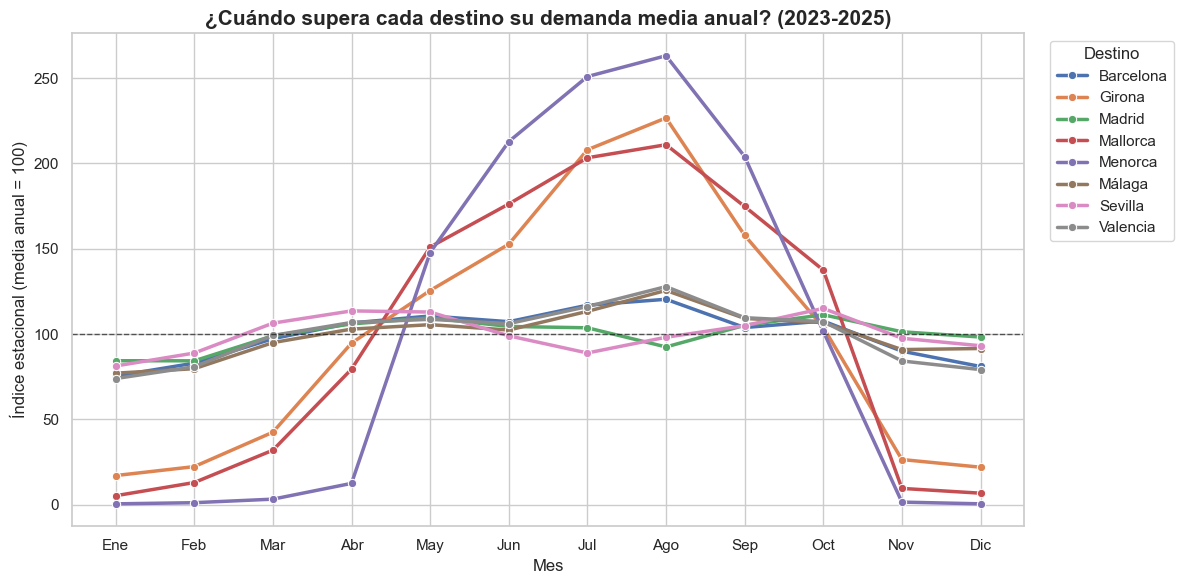

In [349]:
# Preparar datos

demanda_destinos = pd.concat(
    [
        serie_ciudades.rename(columns={"Ciudad": "Destino"})[
            ["Destino", "Mes", "valor"]
        ],
        serie_zonas[
            ["Destino", "Mes", "valor"]
        ]
    ],
    ignore_index=True
)

demanda_media = (
    demanda_destinos
    .groupby(["Destino", "Mes"], as_index=False)
    .agg(
        demanda_media=("valor", "mean")
    )
)

# Índice estacional
# 100 = media anual del destino

demanda_media["indice_estacional"] = (
    demanda_media["demanda_media"]
    /
    demanda_media.groupby("Destino")["demanda_media"].transform("mean")
) * 100


# Todos los destinos de StaySpain

destinos = [
    "Barcelona",
    "Girona",
    "Madrid",
    "Valencia",
    "Málaga",
    "Sevilla",
    "Mallorca",
    "Menorca"
]

grafico = demanda_media[
    demanda_media["Destino"].isin(destinos)
]


plt.figure(figsize=(12,6))

sns.lineplot(
    data=grafico,
    x="Mes",
    y="indice_estacional",
    hue="Destino",
    marker="o",
    linewidth=2.5
)

plt.axhline(
    100,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

plt.title(
    "¿Cuándo supera cada destino su demanda media anual? (2023-2025)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mes")
plt.ylabel("Índice estacional (media anual = 100)")

plt.xticks(
    range(1, 13),
    [
        "Ene", "Feb", "Mar", "Abr", "May", "Jun",
        "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"
    ]
)

plt.legend(
    title="Destino",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Interpretación
- Mallorca y Menorca son los destinos más estacionales.
- Girona también presenta una fuerte concentración estival.
- Barcelona incrementa su demanda en verano, aunque de forma más moderada.
- Madrid es el destino más estable.

## 6.4 Resumen comparativo

Los resultados muestran dos patrones claramente diferenciados.

- Mallorca registra la estacionalidad más intensa.
- Menorca concentra prácticamente toda su demanda en verano.
- Girona presenta un patrón claramente asociado al turismo de costa.
- Barcelona y Madrid muestran una demanda más distribuida durante el año.

## Conclusiones

El análisis confirma que existen diferencias relevantes entre destinos.

Los destinos vacacionales (Mallorca, Menorca y Girona) concentran gran parte de su demanda entre mayo y septiembre, mientras que los destinos urbanos presentan una distribución más equilibrada a lo largo del año.

Estas diferencias indican que la planificación comercial y la gestión de la oferta deberían adaptarse a la estacionalidad específica de cada destino.

#  7.  ¿Está alineada la oferta de StaySpain con la demanda turística en cada destino?

En este apartado se incorpora la información interna de StaySpain para comparar la demanda turística observada en la EOH con las características de la oferta disponible en la plataforma.

El objetivo es identificar si los destinos con mayor demanda turística presentan también una mayor oferta o una mayor ocupación media.

## 7.1 Resumen de la oferta por destino

In [350]:
# Localizar la raíz del proyecto


RUTA = Path("../Data/clean_dataset_13_07_2026.csv")

df_stay = pd.read_csv(RUTA)

In [351]:
# Resumen de la oferta por ciudad
oferta = (
    df_stay
    .groupby("city")
    .agg(
        alojamientos=("apartment_id","nunique"),
        ocupacion_media=("occupancy_rate_365","mean"),
        precio_medio=("price_€","mean"),
        rating=("review_scores_rating","mean")
    )
    .round(2)
    .reset_index()
)
oferta

,city,alojamientos,ocupacion_media,precio_medio,rating
0,Barcelona,2719,49.78,830.15,90.67
1,Girona,1485,46.14,1200.62,90.94
2,Madrid,2134,54.65,791.39,92.63
3,Mallorca,1583,41.39,1655.87,92.97
4,Menorca,218,45.19,1651.16,93.36
5,Málaga,504,45.31,746.04,92.20
6,Sevilla,494,46.23,943.56,93.53
7,Valencia,513,53.43,658.65,92.22


In [352]:
demanda_ciudades = (
    serie_ciudades
    .groupby("Ciudad", as_index=False)
    .agg(
        demanda_media=("valor", "mean")
    )
)

demanda_ciudades

,Ciudad,demanda_media
0,Barcelona,1.807657e+06
1,Madrid,1.732033e+06
2,Málaga,2.919841e+05
3,Sevilla,5.370185e+05
4,Valencia,4.061974e+05


In [353]:
demanda_zonas = (
    serie_zonas
    .groupby("Destino", as_index=False)
    .agg(
        demanda_media=("valor","mean")))

In [354]:
# Unir ciudades e zonas
demanda_total = pd.concat(
    [   demanda_ciudades.rename(columns={"Ciudad":"Destino"}),
        demanda_zonas],
    ignore_index=True)

In [355]:
comparacion = (
    demanda_total
    .merge(
        oferta,
        left_on="Destino",
        right_on="city",
        how="inner"))

comparacion

,Destino,demanda_media,city,alojamientos,ocupacion_media,precio_medio,rating
0,Barcelona,1.807657e+06,Barcelona,2719,49.78,830.15,90.67
1,Madrid,1.732033e+06,Madrid,2134,54.65,791.39,92.63
2,Málaga,2.919841e+05,Málaga,504,45.31,746.04,92.20
3,Sevilla,5.370185e+05,Sevilla,494,46.23,943.56,93.53
4,Valencia,4.061974e+05,Valencia,513,53.43,658.65,92.22
5,Girona,1.001344e+06,Girona,1485,46.14,1200.62,90.94
6,Mallorca,4.011649e+06,Mallorca,1583,41.39,1655.87,92.97
7,Menorca,3.830122e+05,Menorca,218,45.19,1651.16,93.36


### Primera lectura
Los datos de demanda procedentes de la EOH se combinan con los indicadores de oferta de StaySpain para cada destino.

Esta tabla constituye la base para evaluar la relación entre el volumen de demanda turística y el comportamiento de la oferta disponible en la plataforma.

In [356]:
comparacion["demanda_millones"] = (
    comparacion["demanda_media"] / 1_000_000
).round(2)

## 7.2 Relación entre demanda y ocupación media

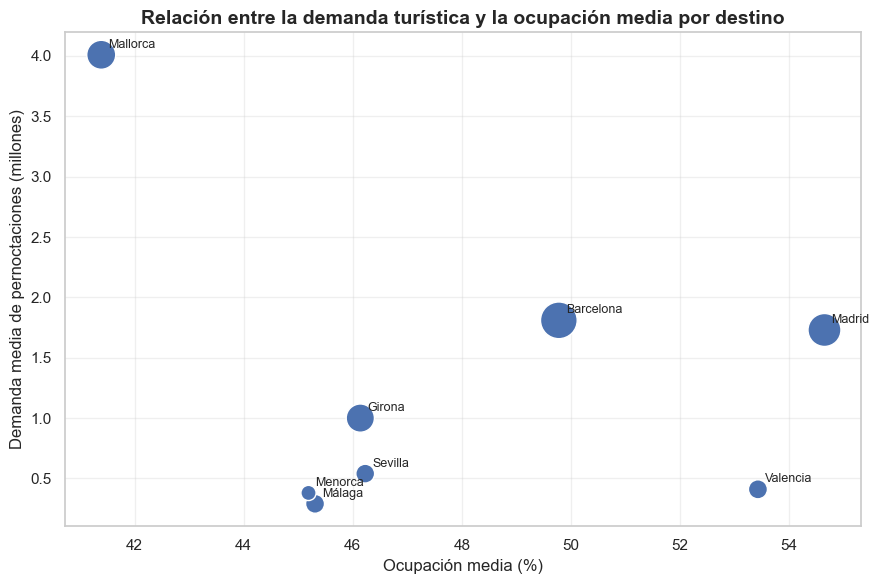

In [357]:
# Relación entre demanda turística y ocupación media

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=comparacion,
    x="ocupacion_media",
    y="demanda_millones",
    size="alojamientos",
    sizes=(120,700),
    legend=False
)
for _, fila in comparacion.iterrows():
    plt.annotate(
        fila["Destino"],          # o "Ciudad" si aún no has renombrado la columna
        (fila["ocupacion_media"], fila["demanda_millones"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title(
    "Relación entre la demanda turística y la ocupación media por destino",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Ocupación media (%)")
plt.ylabel("Demanda media de pernoctaciones (millones)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Interpretación

No se observa una relación lineal entre la demanda turística oficial y la ocupación media registrada por StaySpain.

Mientras Mallorca concentra el mayor volumen de demanda, Madrid presenta la mayor ocupación media de los alojamientos de la plataforma. Barcelona combina una demanda elevada con una ocupación alta, mientras que Valencia muestra una ocupación elevada con un volumen de demanda más moderado.


* Nota metodológica: El gráfico relaciona dos indicadores con unidades distintas (ocupación media de StaySpain y demanda oficial de pernoctaciones de la EOH). El objetivo no es comparar magnitudes, sino analizar si existe una asociación entre el volumen de demanda turística y la ocupación registrada por la plataforma en cada destino.

In [358]:
comparacion.sort_values(
    "demanda_media",
    ascending=False
)

,Destino,demanda_media,city,alojamientos,ocupacion_media,precio_medio,rating,demanda_millones
6,Mallorca,4.011649e+06,Mallorca,1583,41.39,1655.87,92.97,4.01
0,Barcelona,1.807657e+06,Barcelona,2719,49.78,830.15,90.67,1.81
1,Madrid,1.732033e+06,Madrid,2134,54.65,791.39,92.63,1.73
5,Girona,1.001344e+06,Girona,1485,46.14,1200.62,90.94,1.00
3,Sevilla,5.370185e+05,Sevilla,494,46.23,943.56,93.53,0.54
4,Valencia,4.061974e+05,Valencia,513,53.43,658.65,92.22,0.41
7,Menorca,3.830122e+05,Menorca,218,45.19,1651.16,93.36,0.38
2,Málaga,2.919841e+05,Málaga,504,45.31,746.04,92.20,0.29


## 7.3 Comparación entre demanda y ocupación

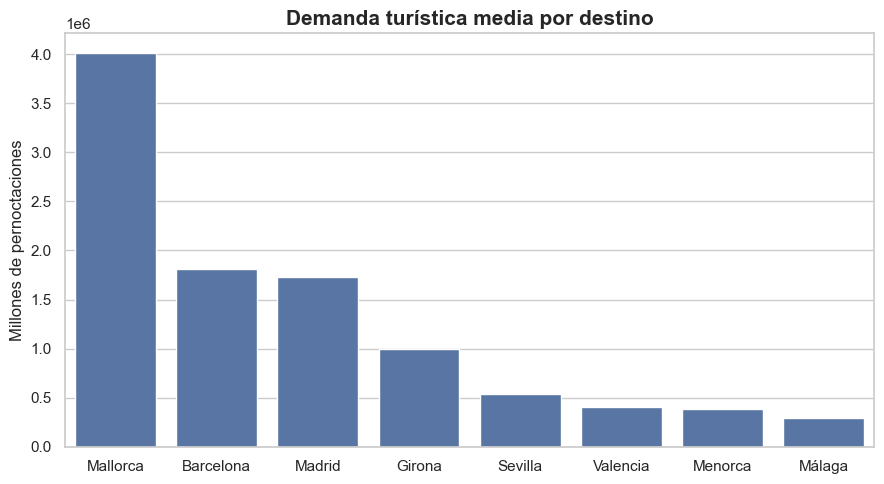

In [359]:
# demanda

plt.figure(figsize=(9,5))

sns.barplot(
    data=comparacion.sort_values("demanda_media", ascending=False),
    x="Destino",
    y="demanda_media"
)

plt.title(
    "Demanda turística media por destino",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Millones de pernoctaciones")

plt.tight_layout()
plt.show()

## Interpretación 

La comparación de ambos gráficos permite observar que el ranking de demanda turística no coincide con el ranking de ocupación de los alojamientos de StaySpain.

Mallorca lidera claramente la demanda turística, mientras que Madrid y Valencia registran las mayores ocupaciones medias de la plataforma. Barcelona mantiene una posición elevada en ambos indicadores, mientras que destinos como Málaga, Sevilla o Menorca presentan niveles intermedios.

En conjunto, los resultados muestran que una mayor demanda turística no implica necesariamente una mayor ocupación de los alojamientos gestionados por StaySpain

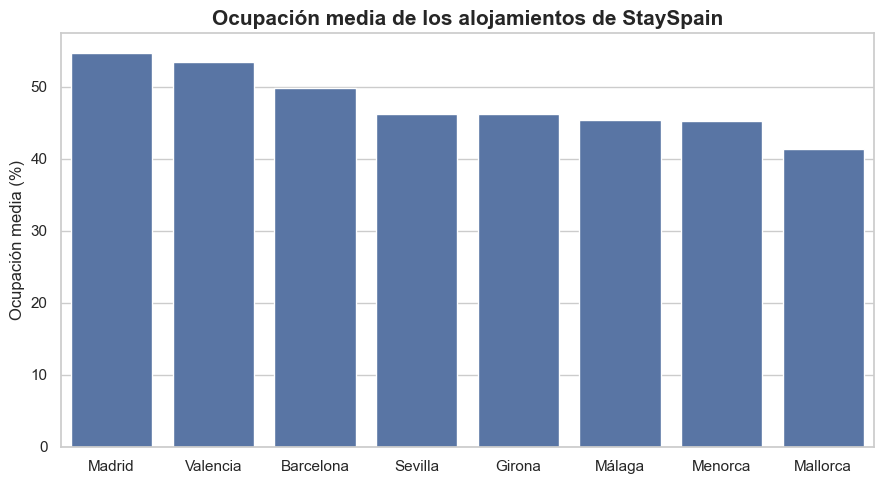

In [360]:
# ocupación 
plt.figure(figsize=(9,5))

sns.barplot(
    data=comparacion.sort_values("ocupacion_media", ascending=False),
    x="Destino",
    y="ocupacion_media"
)

plt.title(
    "Ocupación media de los alojamientos de StaySpain",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Ocupación media (%)")

plt.tight_layout()
plt.show()

## 7.4 Índice de alineación entre oferta y demanda

In [361]:
comparacion["demanda_norm"] = (
    comparacion["demanda_media"]
    /
    comparacion["demanda_media"].max()
)

comparacion["ocupacion_norm"] = (
    comparacion["ocupacion_media"]
    /
    comparacion["ocupacion_media"].max()
)

comparacion["indice_alineacion"] = (
    comparacion["ocupacion_norm"]
    -
    comparacion["demanda_norm"]
)

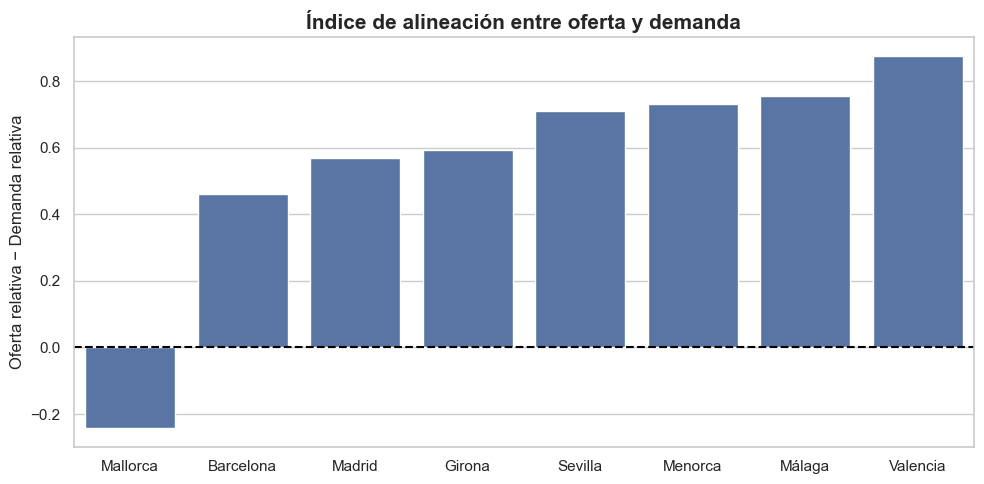

In [362]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparacion.sort_values("indice_alineacion"),
    x="Destino",
    y="indice_alineacion"
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.title(
    "Índice de alineación entre oferta y demanda",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Oferta relativa − Demanda relativa")

plt.tight_layout()
plt.show()

## Interpretación

El índice compara la importancia relativa de la demanda turística con la ocupación media de StaySpain en cada destino.

Mallorca es el único destino con un valor negativo, indicando que su peso dentro de la demanda turística es superior al peso que alcanza la ocupación de los alojamientos de la plataforma. Por el contrario, Valencia, Málaga, Menorca, Sevilla y Madrid presentan valores positivos, lo que refleja una ocupación relativamente elevada respecto a su demanda turística.

Este indicador permite identificar de forma rápida los destinos donde la oferta de StaySpain parece estar más alineada o desalineada con la demanda observada por la EOH.

## 7.5 Respuesta a la pregunta de negocio

#### Conclusiones principales

* Mallorca concentra la mayor demanda turística del estudio.
* Madrid presenta la ocupación media más elevada de los alojamientos de StaySpain.
* Barcelona combina una elevada demanda con una ocupación alta.
* Valencia registra una ocupación elevada pese a tener una demanda turística inferior a la de Barcelona o Mallorca.
* No existe una relación perfectamente proporcional entre la demanda turística oficial y la ocupación media registrada por StaySpain.

#### Conclusión

La oferta de StaySpain no reproduce exactamente la distribución de la demanda turística observada en la EOH. Los resultados muestran que cada destino presenta un comportamiento propio, por lo que la gestión de precios, disponibilidad e inventario debería adaptarse a las características específicas de cada mercado en lugar de aplicar una estrategia uniforme. Este cierre responde directamente a la pregunta de negocio y sirve como conclusión global del proyecto.